In [1]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,AIMessage
import operator

In [2]:
class ChatState(TypedDict):
    history:Annotated[list[str],operator.add]
    user_input:str
    clarification_question:str
    clarification_answer:str
    clarification:bool=Field(description="Clarification require check")
    answer:str

In [3]:
class ClarificationSchema(BaseModel):
    clarification_question:str=Field(description="Clarification asked from llm")
    clarification:bool=Field(description="Clarification require check")

In [4]:
load_dotenv()
model=ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
clarification_model=model.with_structured_output(ClarificationSchema)

In [6]:
def user_input(state:ChatState):
    user=input()
    return {'user_input':user,"history":[HumanMessage(user)]}

In [7]:
def clarification_llm(state:ChatState):
    prompt = f"""
You are a decision-making AI responsible for determining whether a user's query is clear enough to answer.

Your task:
1. Analyze the user's query
2. Decide if it can be answered directly

---

A query is CLEAR if:
- A reasonable and helpful answer can be given
- Even if it is broad, a general overview would still be useful

A query is UNCLEAR only if:
- The intent is impossible to understand
- Multiple completely different interpretations exist
- Answering directly would likely be wrong or misleading

IMPORTANT:
- Broad queries like "AI", "India", "Maurya Empire" are CLEAR
- Do NOT ask follow-up questions repeatedly

---

If the query is CLEAR:
Return ONLY:
{{
  "clarification": true,
  "clarification_question": ""
}}

If the query is UNCLEAR:
- Ask exactly ONE specific clarification question
- Do NOT ask multiple questions
- Do NOT answer the original query

Return ONLY:
{{
  "clarification": false,
  "clarification_question": "<your question>"
}}

---

Rules:
- Never answer the user's query
- Never explain your reasoning
- Output must be valid JSON only
- Do not introduce new keys

---

User Query:
"{state['user_input']}"
"""
    res=clarification_model.invoke(prompt)
    return {'clarification':res.clarification,'clarification_question':res.clarification_question,"history":[AIMessage(res.clarification_question)]}

In [8]:
def route_clarification(state:ChatState):
    if(state['clarification']==True):
        return "clear"
    return "need_clarification"

In [9]:
def clarify(state:ChatState):
    print(state['clarification_question'])
    user=input()
    return {"clarification_answer":user,"history":[HumanMessage(user)]}

In [10]:
def update_question(state:ChatState):
    prompt=f""""
    You are an AI that refines user queries.

Your task:
- Combine the original query and the clarification answer
- Use conversation history ONLY if needed to preserve context
- Produce a single clear and complete query

---

Original Query:
{state['user_input']}

Clarification Question:
{state['clarification_question']}

User's Clarification Answer:
{state['clarification_answer']}

Conversation History (may help for context, ignore if not needed):
{state['history']}

---

Rules:
- Keep the original intent intact
- Incorporate the clarification answer correctly
- Use history only if it adds missing context
- Do NOT repeat the history
- Do NOT ask a question
- Do NOT generate explanations
- Keep it concise and clear (one sentence)

---

Output:
Only return the refined query as plain text."""
    res=model.invoke(prompt).content
    return{"user_input":res, "clarification":True,"clarification_question":"","clarification_answer":""}

In [11]:
def generate_ans(state:ChatState):
    prompt = f"""
You are a helpful AI assistant.

Answer the user's query clearly and concisely.

---

User Query:
{state['user_input']}

---

Rules:
- Keep the answer short (2-3 paragraph max.)
- Use simple and easy-to-understand language
- Be direct and relevant
- Do not ask follow-up questions
- Do not add unnecessary details
- If the query is broad, give a brief general overview

---

Answer:
"""
    res=model.invoke(prompt).content

    return {"answer":res,"history":[AIMessage(res)]}

In [12]:
state=StateGraph(ChatState)

# nodes
state.add_node("user_input",user_input)
state.add_node("clarification_llm",clarification_llm)
state.add_node("clarify",clarify)
state.add_node("generate_ans",generate_ans)
state.add_node("update_question",update_question)
# edges
state.add_edge(START,"user_input")

state.add_edge("user_input","clarification_llm")
state.add_conditional_edges("clarification_llm",route_clarification,{"clear":"generate_ans","need_clarification":"clarify"})
state.add_edge("update_question","clarification_llm")
state.add_edge("clarify","update_question")
state.add_edge("generate_ans",END)


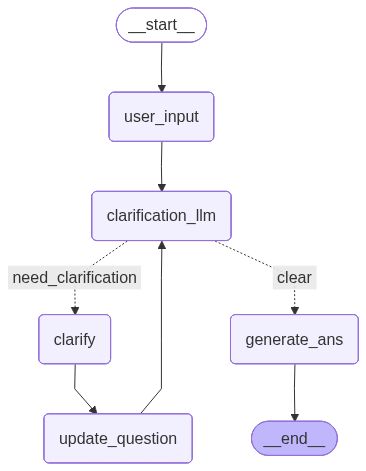

In [13]:
workflow=state.compile()
workflow

In [56]:
workflow.invoke({})

What kind of story would you like me to generate?
What kind of horror story are you looking for, e.g. supernatural, psychological, or slasher?


{'history': [HumanMessage(content='generate a story', additional_kwargs={}, response_metadata={}),
  AIMessage(content='What kind of story would you like me to generate?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='horror story', additional_kwargs={}, response_metadata={}),
  AIMessage(content='What kind of horror story are you looking for, e.g. supernatural, psychological, or slasher?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='psychological', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='In the small town of Ravenswood, a mysterious figure known as "The Whisperer" began to appear in people\'s dreams. At first, the dreams were harmless, but soon they turned into terrifying nightmares. The Whisperer would whisper a single phrase in th

In [ ]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, AIMessage
import operator
from langchain.tools import tool
import requests
import os

# -------------------- STATE --------------------

class ChatState(TypedDict):
    history: Annotated[list, operator.add]
    user_input: str
    clarification_question: str
    clarification_answer: str
    action: str
    answer: str

# -------------------- SCHEMA --------------------

class DecisionSchema(BaseModel):
    action: Literal["clarify", "tool", "answer"]
    clarification_question: str = ""

# -------------------- MODEL --------------------

load_dotenv()
model = ChatGroq(model="llama-3.3-70b-versatile")
decision_model = model.with_structured_output(DecisionSchema)

# -------------------- TOOL --------------------

@tool
def weather_tool(location: str):
    """Get current weather for a location."""

    API_KEY=os.getenv("WEATHER_API_KEY")
    url = f"http://api.weatherapi.com/v1/current.json?key={API_KEY}&q={location}"
    response = requests.get(url).json()

    return f"{response['location']['name']}: {response['current']['temp_c']}°C, {response['current']['condition']['text']}"

# bind tool
model_with_tools = model.bind_tools([weather_tool])

# -------------------- INPUT --------------------

def user_input(state: ChatState):
    user = input("User: ")
    return {"user_input": user, "history": [HumanMessage(user)]}
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, AIMessage
import operator
from langchain.tools import tool
import requests
import os

# -------------------- STATE --------------------

class ChatState(TypedDict):
    history: Annotated[list, operator.add]
    user_input: str
    clarification_question: str
    clarification_answer: str
    action: str
    answer: str

# -------------------- SCHEMA --------------------

class DecisionSchema(BaseModel):
    action: Literal["clarify", "tool", "answer"]
    clarification_question: str = ""

# -------------------- MODEL --------------------

load_dotenv()
model = ChatGroq(model="llama-3.3-70b-versatile")
decision_model = model.with_structured_output(DecisionSchema)

# -------------------- TOOL --------------------

@tool
def weather_tool(location: str):
    """Get current weather for a location."""

    API_KEY=os.getenv("WEATHER_API_KEY")
    url = f"http://api.weatherapi.com/v1/current.json?key={API_KEY}&q={location}"
    response = requests.get(url).json()

    return f"{response['location']['name']}: {response['current']['temp_c']}°C, {response['current']['condition']['text']}"

# bind tool
model_with_tools = model.bind_tools([weather_tool])

# -------------------- INPUT --------------------

def user_input(state: ChatState):
    user = input("User: ")
    return {"user_input": user, "history": [HumanMessage(user)]}

# -------------------- DECISION --------------------

def decision_llm(state: ChatState):
    prompt = f"""
Decide what to do with this query.

Actions:
- "clarify" → if unclear
- "tool" → if weather-related
- "answer" → otherwise

Query:
{state['user_input']}

Return JSON:
{{
  "action": "...",
  "clarification_question": "..."
}}
"""
    res = decision_model.invoke(prompt)

    return {
        "action": res.action,
        "clarification_question": res.clarification_question,
        "history": [AIMessage(res.clarification_question if res.action == "clarify" else "")]
    }

# -------------------- CLARIFY --------------------

def clarify(state: ChatState):
    print("AI:", state["clarification_question"])
    user = input("User: ")
    return {
        "user_input": user,
        "history": [HumanMessage(user)]
    }

# -------------------- AGENT (WITH TOOL CALLING) --------------------

def agent_node(state: ChatState):
    response = model_with_tools.invoke(state["history"])
    return {"history": [response]}

# -------------------- TOOL EXECUTION --------------------

def tool_node(state: ChatState):
    last = state["history"][-1]
    results = []

    for call in last.tool_calls:
        if call["name"] == "weather_tool":
            result = weather_tool.invoke(call["args"])
            results.append(AIMessage(content=result))

    return {"history": results}

# -------------------- ANSWER --------------------

def generate_ans(state: ChatState):
    prompt = f"Answer clearly:\n{state['user_input']}"
    res = model.invoke(prompt).content
    return {"answer": res, "history": [AIMessage(res)]}

# -------------------- ROUTING --------------------

def route_decision(state: ChatState):
    if state["action"] == "clarify":
        return "clarify"
    elif state["action"] == "tool":
        return "tool"
    else:
        return "answer"

def route_tool(state: ChatState):
    last = state["history"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tool"
    return "end"

# -------------------- GRAPH --------------------

graph = StateGraph(ChatState)

graph.add_node("user_input", user_input)
graph.add_node("decision_llm", decision_llm)
graph.add_node("clarify", clarify)

# NEW
graph.add_node("agent_node", agent_node)
graph.add_node("tool_node", tool_node)

graph.add_node("generate_ans", generate_ans)

graph.add_edge(START, "user_input")
graph.add_edge("user_input", "decision_llm")

graph.add_conditional_edges(
    "decision_llm",
    route_decision,
    {
        "clarify": "clarify",
        "tool": "agent_node",
        "answer": "generate_ans"
    }
)

# tool loop
graph.add_conditional_edges(
    "agent_node",
    route_tool,
    {
        "tool": "tool_node",
        "end": "generate_ans"
    }
)

graph.add_edge("tool_node", "agent_node")
graph.add_edge("generate_ans", END)

workflow = graph.compile()
# -------------------- DECISION --------------------

def decision_llm(state: ChatState):
    prompt = f"""
Decide what to do with this query.

Actions:
- "clarify" → if unclear
- "tool" → if weather-related
- "answer" → otherwise

Query:
{state['user_input']}

Return JSON:
{{
  "action": "...",
  "clarification_question": "..."
}}
"""
    res = decision_model.invoke(prompt)

    return {
        "action": res.action,
        "clarification_question": res.clarification_question,
        "history": [AIMessage(res.clarification_question if res.action == "clarify" else "")]
    }

# -------------------- CLARIFY --------------------

def clarify(state: ChatState):
    print("AI:", state["clarification_question"])
    user = input("User: ")
    return {
        "user_input": user,
        "history": [HumanMessage(user)]
    }

# -------------------- AGENT (WITH TOOL CALLING) --------------------

def agent_node(state: ChatState):
    response = model_with_tools.invoke(state["history"])
    return {"history": [response]}

# -------------------- TOOL EXECUTION --------------------

def tool_node(state: ChatState):
    last = state["history"][-1]
    results = []

    for call in last.tool_calls:
        if call["name"] == "weather_tool":
            result = weather_tool.invoke(call["args"])
            results.append(AIMessage(content=result))

    return {"history": results}

# -------------------- ANSWER --------------------

def generate_ans(state: ChatState):
    prompt = f"Answer clearly:\n{state['user_input']}"
    res = model.invoke(prompt).content
    return {"answer": res, "history": [AIMessage(res)]}

# -------------------- ROUTING --------------------

def route_decision(state: ChatState):
    if state["action"] == "clarify":
        return "clarify"
    elif state["action"] == "tool":
        return "tool"
    else:
        return "answer"

def route_tool(state: ChatState):
    last = state["history"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tool"
    return "end"

# -------------------- GRAPH --------------------

graph = StateGraph(ChatState)

graph.add_node("user_input", user_input)
graph.add_node("decision_llm", decision_llm)
graph.add_node("clarify", clarify)

# NEW
graph.add_node("agent_node", agent_node)
graph.add_node("tool_node", tool_node)

graph.add_node("generate_ans", generate_ans)

graph.add_edge(START, "user_input")
graph.add_edge("user_input", "decision_llm")

graph.add_conditional_edges(
    "decision_llm",
    route_decision,
    {
        "clarify": "clarify",
        "tool": "agent_node",
        "answer": "generate_ans"
    }
)

# tool loop
graph.add_conditional_edges(
    "agent_node",
    route_tool,
    {
        "tool": "tool_node",
        "end": "generate_ans"
    }
)

graph.add_edge("tool_node", "agent_node")
graph.add_edge("generate_ans", END)

workflow = graph.compile()

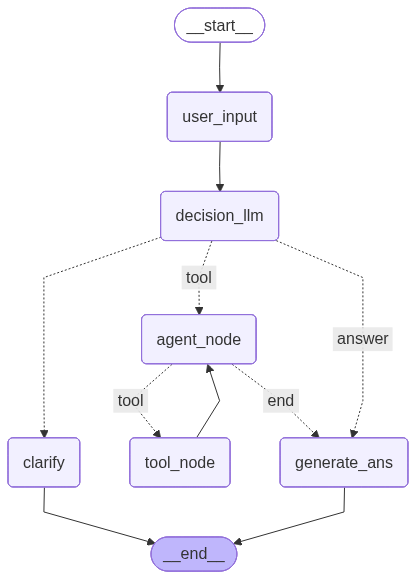

In [11]:
workflow

In [12]:
workflow.invoke({})

{'history': [HumanMessage(content='what is weather in delhi', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '674ydsar2', 'function': {'arguments': '{"location":"Delhi"}', 'name': 'weather_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 218, 'total_tokens': 234, 'completion_time': 0.040807138, 'completion_tokens_details': None, 'prompt_time': 0.021404888, 'prompt_tokens_details': None, 'queue_time': 0.165132285, 'total_time': 0.062212026}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db452-476c-7db1-9026-747db7afab7b-0', tool_calls=[{'name': 'weather_tool', 'args': {'location': 'Delhi'}, 'id': '674ydsar2', '